[Text(0, 0, 'Vis_1'),
 Text(0, 5, 'Vis_6'),
 Text(0, 10, 'Vis_11'),
 Text(0, 15, 'SomMot_2'),
 Text(0, 20, 'SomMot_7'),
 Text(0, 25, 'SomMot_12'),
 Text(0, 30, 'DorsAttn_Post_1'),
 Text(0, 35, 'DorsAttn_Post_6'),
 Text(0, 40, 'DorsAttn_FEF_1'),
 Text(0, 45, 'SalVentAttn_ParOper_3'),
 Text(0, 50, 'SalVentAttn_PFCl_1'),
 Text(0, 55, 'Limbic_OFC_2'),
 Text(0, 60, 'Cont_Par_1'),
 Text(0, 65, 'Cont_PFCl_1'),
 Text(0, 70, 'Cont_pCun_1'),
 Text(0, 75, 'Default_Temp_3'),
 Text(0, 80, 'Default_Par_3'),
 Text(0, 85, 'Default_PFC_4'),
 Text(0, 90, 'Default_PFC_9'),
 Text(0, 95, 'Default_pCunPCC_1')]

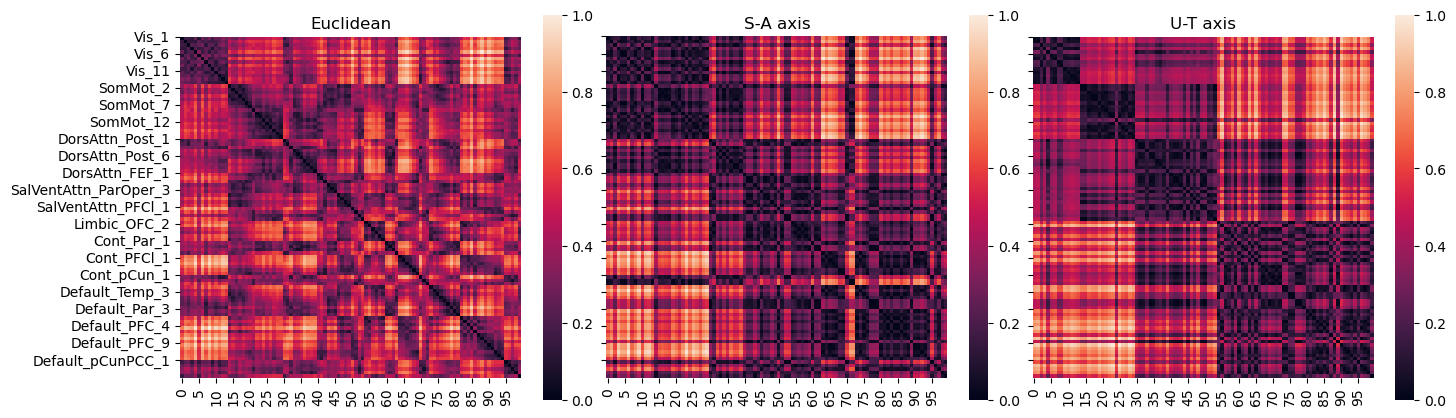

In [41]:
from src import utils
import numpy as np
from scipy.spatial import distance
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

maps = [
    [ 'Euclidean', '../data/schaefer200_centroids.csv' ],
    [ 'S-A axis',  '../data/schaefer200_sa-axis.npy'   ],
    [ 'U-T axis',  '../data/schaefer200_ut-axis.npy'   ]
]

n_maps = len(maps)

# euclidean
centroids = pd.read_csv(maps[0][1])[:100]
roi_names = centroids['ROI Name'].str.replace('7Networks_LH_','')
centroids.set_index("ROI Name", inplace=True)
brain_map = centroids.to_numpy()
maps[0].append(utils.normalize_x(utils.get_brainmap_distance(brain_map)))

# s-a axis
brain_map = np.load(maps[1][1])[:100]
maps[1].append(utils.normalize_x(utils.get_brainmap_distance(brain_map)))

# u-t axis
brain_map = np.load(maps[2][1])[:100]
maps[2].append(utils.normalize_x(utils.get_brainmap_distance(brain_map)))

# plot
h = 5
w = h * 1.1 * n_maps
fig, ax = plt.subplots(1, n_maps, figsize=(w,h), squeeze=True, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0)
for ii in np.arange(n_maps):
    sns.heatmap(maps[ii][2], ax=fig.axes[ii], cbar=1)
    fig.axes[ii].set_aspect('equal')
    fig.axes[ii].set_title(maps[ii][0])
yticks = np.arange(0,100,5)
fig.axes[0].set_yticks(yticks)
fig.axes[0].set_yticklabels(roi_names[yticks])
